<a href="https://colab.research.google.com/github/Faizaa01/Deep_Learning_Practices/blob/main/DL_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(42)

In [3]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [5]:
df = pd.read_csv("/content/fmnist_small.csv")
df

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,1,0,0,0,0,0,0,0,0,0,...,69,12,0,0,0,0,0,0,0,0
5996,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5997,8,0,0,0,0,0,0,0,0,0,...,39,47,2,0,0,29,0,0,0,0
5998,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


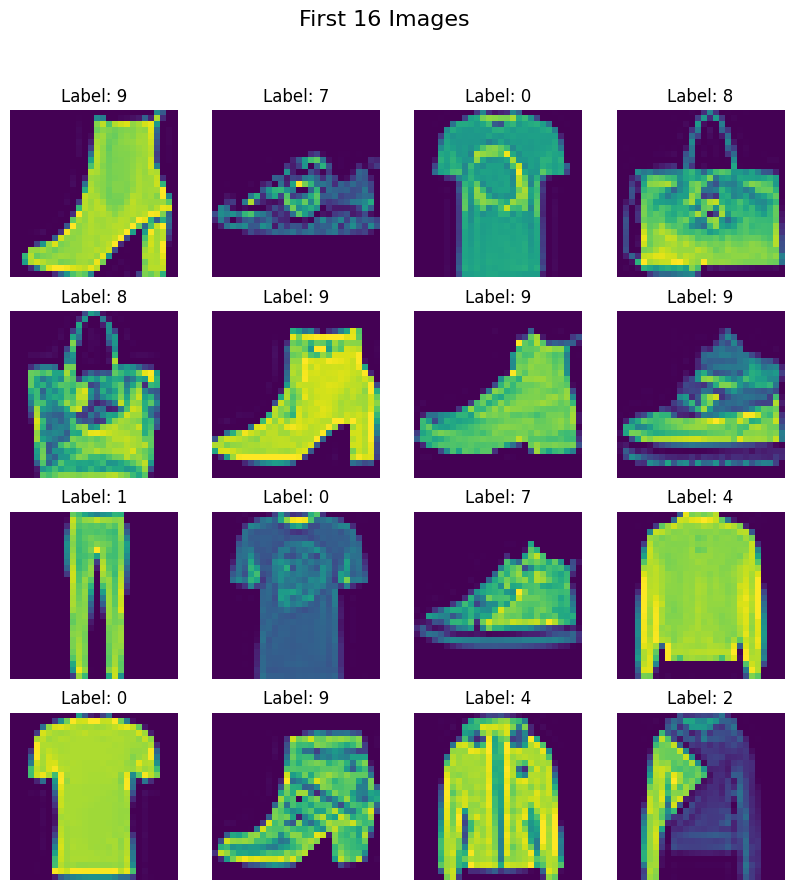

In [6]:
fig, axes = plt.subplots(4,4, figsize=(10,10))
fig.suptitle("First 16 Images", fontsize=16)

for i,ax in enumerate(axes.flat):
  img = df.iloc[i, 1:].values.reshape(28,28)
  ax.imshow(img)
  ax.axis('off')

  ax.set_title(f"Label: {df.iloc[i,0]}")

In [7]:
len(df.columns), len(df["label"].unique()), len(df.iloc[:,1:])

(785, 10, 6000)

In [8]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = X_train/255.0
X_test = X_test/255.0

In [9]:
class CustomDataset(Dataset):
    def __init__(self, features, labels):
      self.features = torch.tensor(features, dtype=torch.float32)
      self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
      return len(self.features)

    def __getitem__(self, index):
      return self.features[index], self.labels[index]

In [10]:
train_dataset = CustomDataset(X_train,y_train)
test_dataset = CustomDataset(X_test,y_test)

len(train_dataset), len(test_dataset)

(4800, 1200)

In [11]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False, pin_memory=True)
# train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
# test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False)

In [12]:
class MyNN(nn.Module):
  def __init__(self, num_features):
    super().__init__()

    self.model = nn.Sequential(
        nn.Linear(num_features, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10),
    )

  def forward(self, x):
    return self.model(x)

In [13]:
epochs =10
learning_rate = 0.1

model = MyNN(X_train.shape[1])
model = model.to(device)

criterion  = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

In [14]:
for epoch in range(epochs):
  total_epoch_loss = 0

  for batch_features, batch_labels in train_loader:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    output = model(batch_features)

    loss = criterion(output, batch_labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_epoch_loss += loss.item()


avg_loss = total_epoch_loss / len(train_loader)
avg_loss

0.39741520086924237

In [15]:
model.eval()

total = 0
correct = 0
with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

        outputs = model(batch_features)
        _, predicted = torch.max(outputs, 1)

        total += batch_labels.shape[0]
        correct += (predicted == batch_labels).sum().item()

accuracy = correct / total
print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"total number of images: {total}")
print(f"number of correct predictions: {correct}")

Test Accuracy: 83.25%
total number of images: 1200
number of correct predictions: 999
